# False Analysis Notebook (Siamese Verification)

This notebook helps you **understand errors (FP/FN)**, and inspect the hardest pairs.

**Assumptions**
- Your project structure matches `src/` as in training.
- You have a finished run directory under `outputs/<experiment_name>/` containing `best.pt` and/or `final.pt`.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
from pathlib import Path

REPO_URL = "https://github.com/yehonatan768/Facial_Recognition.git"   # change
DEST_DIR = Path("/content/Face_Recognition")            # choose folder name

if DEST_DIR.exists():
    print("Repo folder already exists:", DEST_DIR)
else:
    !git clone {REPO_URL} {DEST_DIR}

%cd /content/Face_Recognition
!git status

Cloning into '/content/Face_Recognition'...
remote: Enumerating objects: 1029, done.
remote: Counting objects: 100% (235/235), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 1029 (delta 163), reused 164 (delta 109), pack-reused 794 (from 1)
Receiving objects: 100% (1029/1029), 6.26 MiB | 27.16 MiB/s, done.
Resolving deltas: 100% (609/609), done.
/content/Face_Recognition
On branch master
Your branch is up to date with 'origin/master'.

nothing to commit, working tree clean


In [4]:
!git checkout Sprint-3

Branch 'Sprint-3' set up to track remote branch 'Sprint-3' from 'origin'.
Switched to a new branch 'Sprint-3'


In [5]:
from pathlib import Path
import shutil

ZIP_ON_DRIVE = Path("/content/drive/MyDrive/Facial_Recognition/lfwa.zip")  # change if needed
ZIP_LOCAL = Path("/content/lfwa.zip")

shutil.copy2(ZIP_ON_DRIVE, ZIP_LOCAL)
print("Copied ZIP to local:", ZIP_LOCAL)


import zipfile
from pathlib import Path
import shutil

ZIP_LOCAL = Path("/content/lfwa.zip")
IMAGES_DIR = Path("/content/Face_Recognition/images")

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

prefix = "lfw2/lfw2/"

with zipfile.ZipFile(ZIP_LOCAL) as z:
    for member in z.namelist():
        if member.startswith(prefix) and not member.endswith("/"):
            rel = Path(member).parts[len(Path(prefix).parts):]
            out = IMAGES_DIR.joinpath(*rel)

            out.parent.mkdir(parents=True, exist_ok=True)
            with z.open(member) as src, open(out, "wb") as dst:
                shutil.copyfileobj(src, dst)

print("Extracted locally into:", IMAGES_DIR)

Copied ZIP to local: /content/lfwa.zip
Extracted locally into: /content/Face_Recognition/images


In [9]:
!python -m src.run.train --config_dir src/config --outdir outputs

2025-12-31 12:58:18,177 | INFO | train | Device: cuda
2025-12-31 12:58:32,310 | INFO | train | [Split] train pairs: n=1760 pos_frac=0.507 | val pairs: n=440 pos_frac=0.473 | target_val_pairs=440 target_pos_frac=0.50
2025-12-31 12:58:32,310 | INFO | train | [Split] train_ids=1844 | val_ids=288 | components=1032
2025-12-31 12:58:32,311 | INFO | train | Validation source: split_from_train (train_txt=/content/Face_Recognition/assets/pairsDevTrain.txt)
2025-12-31 12:58:32,312 | INFO | train | Loaded train pairs: 1760
2025-12-31 12:58:32,312 | INFO | train | Loaded val pairs: 440
2025-12-31 12:58:44,643 | INFO | train | Epoch 001/200 | loss: train=0.915506 val=0.683008 | acc: train=0.5223 val=0.5386 | lr=0.01000000 m=0.5080
2025-12-31 12:58:55,331 | INFO | train | Epoch 002/200 | loss: train=0.703483 val=0.703528 | acc: train=0.5552 val=0.5682 | lr=0.00985000 m=0.5160
2025-12-31 12:59:05,226 | INFO | train | Epoch 003/200 | loss: train=0.684718 val=0.643516 | acc: train=0.5798 val=0.6341 | l

In [16]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# -------------------------
# Set these
# -------------------------
PROJECT_ROOT = Path.cwd().resolve()
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"
EXP_NAME = None


In [17]:
# -------------------------
# Resolve run_dir
# -------------------------
def pick_latest_run(outputs_root: Path) -> Path:
    cands = [p for p in outputs_root.iterdir() if p.is_dir()]
    if not cands:
        raise FileNotFoundError(f"No runs found in {outputs_root}")
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

if EXP_NAME is None:
    run_dir = pick_latest_run(OUTPUTS_ROOT)
else:
    run_dir = OUTPUTS_ROOT / EXP_NAME

run_dir


PosixPath('/content/Face_Recognition/outputs/siamese_verification')

In [18]:
# -------------------------
# Load config (prefer merged)
# -------------------------
import yaml
from src.utils.read_config import load_config_files

def _config_paths(config_dir: Path):
    names = [
        "paths.yaml",
        "model.yaml",
        "optim.yaml",
        "train.yaml",
        "transform.yaml",
        "logging.yaml",
        "experiment.yaml",
    ]
    return [config_dir / n for n in names if (config_dir / n).exists()]

merged_cfg_path = run_dir / "config_merged.yaml"
if merged_cfg_path.exists():
    cfg = yaml.safe_load(merged_cfg_path.read_text())
else:
    # fallback: load from repo config dir
    config_dir = PROJECT_ROOT / "src" / "config"
    cfg = load_config_files(_config_paths(config_dir))

cfg.keys()


dict_keys(['paths', 'model', 'optim', 'train', 'split', 'data', 'transform', 'logging', 'experiment'])

In [19]:
# -------------------------
# Build model exactly like training
# -------------------------
from src.model.cnn_embedder import ConvEmbeddingConfig, ConvEmbeddingNet
from src.model.head import SimilarityHeadConfig, WeightedL1Head
from src.model.siamese import SiameseNet
from src.model.init import init_weights_like_reference

def infer_hw_from_cfg(cfg: dict):
    # Keep consistent with training: prefer transform.size as square
    size = int(cfg.get("transform", {}).get("size", 105))
    return size, size

enc_cfg = ConvEmbeddingConfig(**cfg["model"]["encoder"])
_ = SimilarityHeadConfig(**cfg["model"]["head"])  # kept for completeness

encoder = ConvEmbeddingNet(enc_cfg)
head = WeightedL1Head(dim=int(enc_cfg.fc_out))
model = SiameseNet(encoder=encoder, head=head).to(device)

# init + materialize FC like training
init_weights_like_reference(model)
H, W = infer_hw_from_cfg(cfg)
C = int(enc_cfg.in_channels)
with torch.no_grad():
    dummy1 = torch.zeros((1, C, H, W), device=device, dtype=torch.float32)
    dummy2 = torch.zeros((1, C, H, W), device=device, dtype=torch.float32)
    _ = model(dummy1, dummy2)

model.eval()


SiameseNet(
  (encoder): ConvEmbeddingNet(
    (conv1): Conv2d(1, 64, kernel_size=(10, 10), stride=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(7, 7), stride=(1, 1))
    (conv3): Conv2d(128, 128, kernel_size=(4, 4), stride=(1, 1))
    (conv4): Conv2d(128, 256, kernel_size=(4, 4), stride=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn4): Identity()
    (act): LeakyReLU(negative_slope=0.1, inplace=True)
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (fc): Linear(in_features=9216, out_features=1024, bias=True)
    (sigmoid): Sigmoid()
  )
  (head): WeightedL1Head()
)

In [20]:
# -------------------------
# Load checkpoint (prefer final.pt if it exists)
# -------------------------
ckpt_path = run_dir / "final.pt"
if not ckpt_path.exists():
    ckpt_path = run_dir / "best.pt"
if not ckpt_path.exists():
    raise FileNotFoundError(f"No checkpoint found in {run_dir} (expected final.pt or best.pt)")

ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"], strict=True)
print("Loaded:", ckpt_path)


Loaded: /content/Face_Recognition/outputs/siamese_verification/best.pt


In [21]:
# -------------------------
# Build dataset/loader for TEST (or VAL)
# -------------------------
from src.data.load_pairs import parse_pairs_file
from src.data.transforms import build_transform
from torch.utils.data import DataLoader
from src.data.datasets import PairPathDataset, Pair

paths = cfg["paths"]
images_root = (PROJECT_ROOT / str(paths["images_root"])).resolve()
pairs_test_path = (PROJECT_ROOT / str(paths["pairs_test"])).resolve()

eval_transform = build_transform(cfg, train=False)

test_pairs: list[Pair] = parse_pairs_file(pairs_test_path, images_root=images_root)
print("test_pairs:", len(test_pairs))

bs = int(cfg.get("optim", {}).get("batch_size", 128))
test_ds = PairPathDataset(test_pairs, transform=eval_transform)
test_loader = DataLoader(test_ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=False)


test_pairs: 1000


In [38]:
# -------------------------
# Run inference and save raw predictions (SRC-compatible)
# -------------------------
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch
from pathlib import Path

def identity_from_path(p: Path) -> str:
    return p.parent.name

records = []
model.eval()

offset = 0
with torch.no_grad():
    for x1, x2, y in tqdm(test_loader, total=len(test_loader)):
        bsz = int(y.shape[0])

        batch_pairs = test_pairs[offset : offset + bsz]
        offset += bsz

        x1 = x1.to(device, non_blocking=True)
        x2 = x2.to(device, non_blocking=True)

        # y comes from dataset; keep as int for saving
        y_np = y.detach().cpu().numpy().astype(int)

        # ---- Model output in this repo: logits ONLY (B,1) ----
        logits = model(x1, x2)                 # (B,1)
        probs = torch.sigmoid(logits).squeeze(1)  # (B,)
        p_same = probs.detach().cpu().numpy()

        # ---- Get embeddings explicitly from encoder ----
        e1 = model.encoder(x1)   # (B,D)
        e2 = model.encoder(x2)   # (B,D)
        e1_np = e1.detach().cpu().numpy()
        e2_np = e2.detach().cpu().numpy()

        for i, (p1, p2, _) in enumerate(batch_pairs):
            img1 = Path(p1)
            img2 = Path(p2)

            records.append({
                "img1": str(img1),
                "img2": str(img2),
                "id1": identity_from_path(img1),
                "id2": identity_from_path(img2),
                "y_true": int(y_np[i]),
                "score": float(p_same[i]),        # probability of "same"
                "logit": float(logits[i].item()), # optional but useful
                "e1": e1_np[i].tolist(),
                "e2": e2_np[i].tolist(),
            })

df = pd.DataFrame(records)

fa_dir = run_dir / "false_analysis"
fa_dir.mkdir(parents=True, exist_ok=True)

csv_path = fa_dir / "raw_predictions.csv"
df.to_csv(csv_path, index=False)

print("Saved:", csv_path)
df.head()


  0%|          | 0/8 [00:00<?, ?it/s]

Saved: /content/Face_Recognition/outputs/siamese_verification/false_analysis/raw_predictions.csv


,img1,img2,id1,id2,y_true,score,logit,e1,e2
0,/content/Face_Recognition/images/Abdullah_Gul/...,/content/Face_Recognition/images/Abdullah_Gul/...,Abdullah_Gul,Abdullah_Gul,1,0.416146,-0.338617,"[1.0, 2.28966260014396e-13, 1.0, 0.88809603452...","[1.0, 5.907326888159698e-19, 1.0, 1.0, 0.99993..."
1,/content/Face_Recognition/images/Abdullah_Gul/...,/content/Face_Recognition/images/Abdullah_Gul/...,Abdullah_Gul,Abdullah_Gul,1,0.298154,-0.856103,"[1.0, 2.28966260014396e-13, 1.0, 0.88809603452...","[1.0, 7.079785646624259e-10, 1.0, 1.0, 0.99999..."
2,/content/Face_Recognition/images/Abdullatif_Se...,/content/Face_Recognition/images/Abdullatif_Se...,Abdullatif_Sener,Abdullatif_Sener,1,0.205792,-1.350477,"[1.0, 5.097390406438987e-19, 1.0, 0.9999994039...","[1.0, 3.4025723455151716e-14, 1.0, 0.987113833..."
3,/content/Face_Recognition/images/Adel_Al-Jubei...,/content/Face_Recognition/images/Adel_Al-Jubei...,Adel_Al-Jubeir,Adel_Al-Jubeir,1,0.495395,-0.018420,"[1.0, 3.158286084887418e-20, 0.999997496604919...","[1.0, 7.273558059563069e-22, 1.0, 0.9999612569..."
4,/content/Face_Recognition/images/Al_Pacino/Al_...,/content/Face_Recognition/images/Al_Pacino/Al_...,Al_Pacino,Al_Pacino,1,0.659023,0.658941,"[1.0, 6.5400410610142656e-18, 1.0, 1.0, 0.9999...","[1.0, 1.262294091475269e-08, 1.0, 1.0, 0.99999..."


In [39]:
import pandas as pd

df = pd.read_csv(run_dir / "false_analysis" / "raw_predictions.csv")

tau = 0.5
dfa = apply_threshold(df, tau)

acc = (dfa["y_pred"] == dfa["y_true"]).mean()
fp = (dfa["error_type"] == "FP").sum()
fn = (dfa["error_type"] == "FN").sum()

print(f"tau={tau:.3f} | test accuracy={acc:.4f} | FP={fp} | FN={fn}")


tau=0.500 | test accuracy=0.6480 | FP=171 | FN=181


In [40]:
# -------------------------
# Optional: find best tau by maximizing accuracy on THIS set
# (Use this only for analysis; do not report this as 'final test accuracy')
# -------------------------
taus = np.linspace(0.0, 1.0, 1001)
scores = df["score"].values
y_true = df["y_true"].values

best = (-1.0, 0.5)
for t in taus:
    y_pred = (scores >= t).astype(int)
    a = (y_pred == y_true).mean()
    if a > best[0]:
        best = (a, t)

print("best_acc_on_this_set=", best[0], "best_tau=", best[1])


best_acc_on_this_set= 0.657 best_tau= 0.406


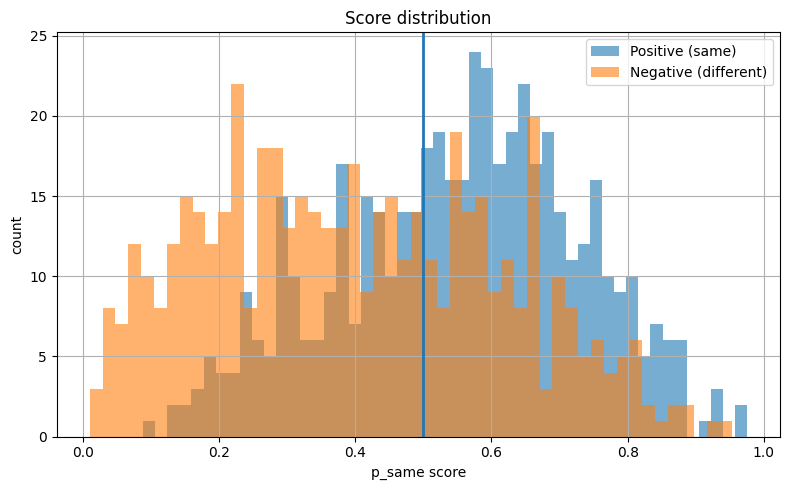

In [41]:
# -------------------------
# Score distributions (pos vs neg)
# -------------------------
pos = df[df.y_true == 1]["score"].values
neg = df[df.y_true == 0]["score"].values

plt.figure(figsize=(8,5))
plt.hist(pos, bins=50, alpha=0.6, label="Positive (same)")
plt.hist(neg, bins=50, alpha=0.6, label="Negative (different)")
plt.axvline(tau, linewidth=2)
plt.title("Score distribution")
plt.xlabel("p_same score")
plt.ylabel("count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


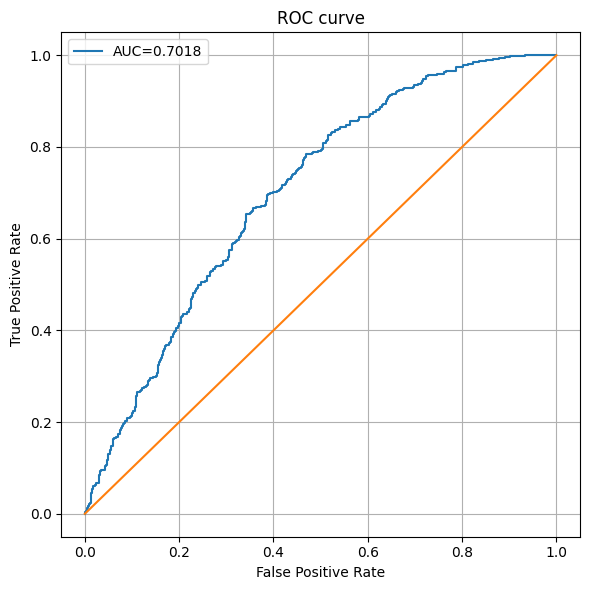

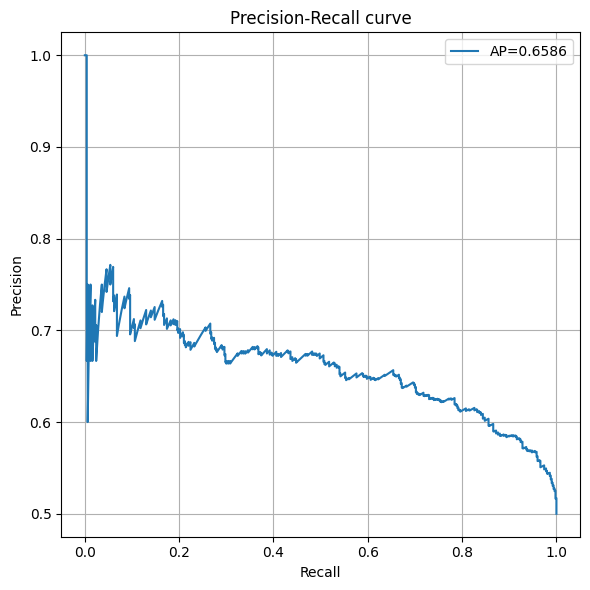

In [42]:
# -------------------------
# ROC / PR curves
# -------------------------
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1], [0,1])
plt.title("ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

prec, rec, _ = precision_recall_curve(y_true, scores)
ap = average_precision_score(y_true, scores)

plt.figure(figsize=(6,6))
plt.plot(rec, prec, label=f"AP={ap:.4f}")
plt.title("Precision-Recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [43]:
# -------------------------
# Confusion matrix at chosen tau
# -------------------------
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(dfa["y_true"], dfa["y_pred"], labels=[0,1])
cm


array([[329, 171],
       [181, 319]])

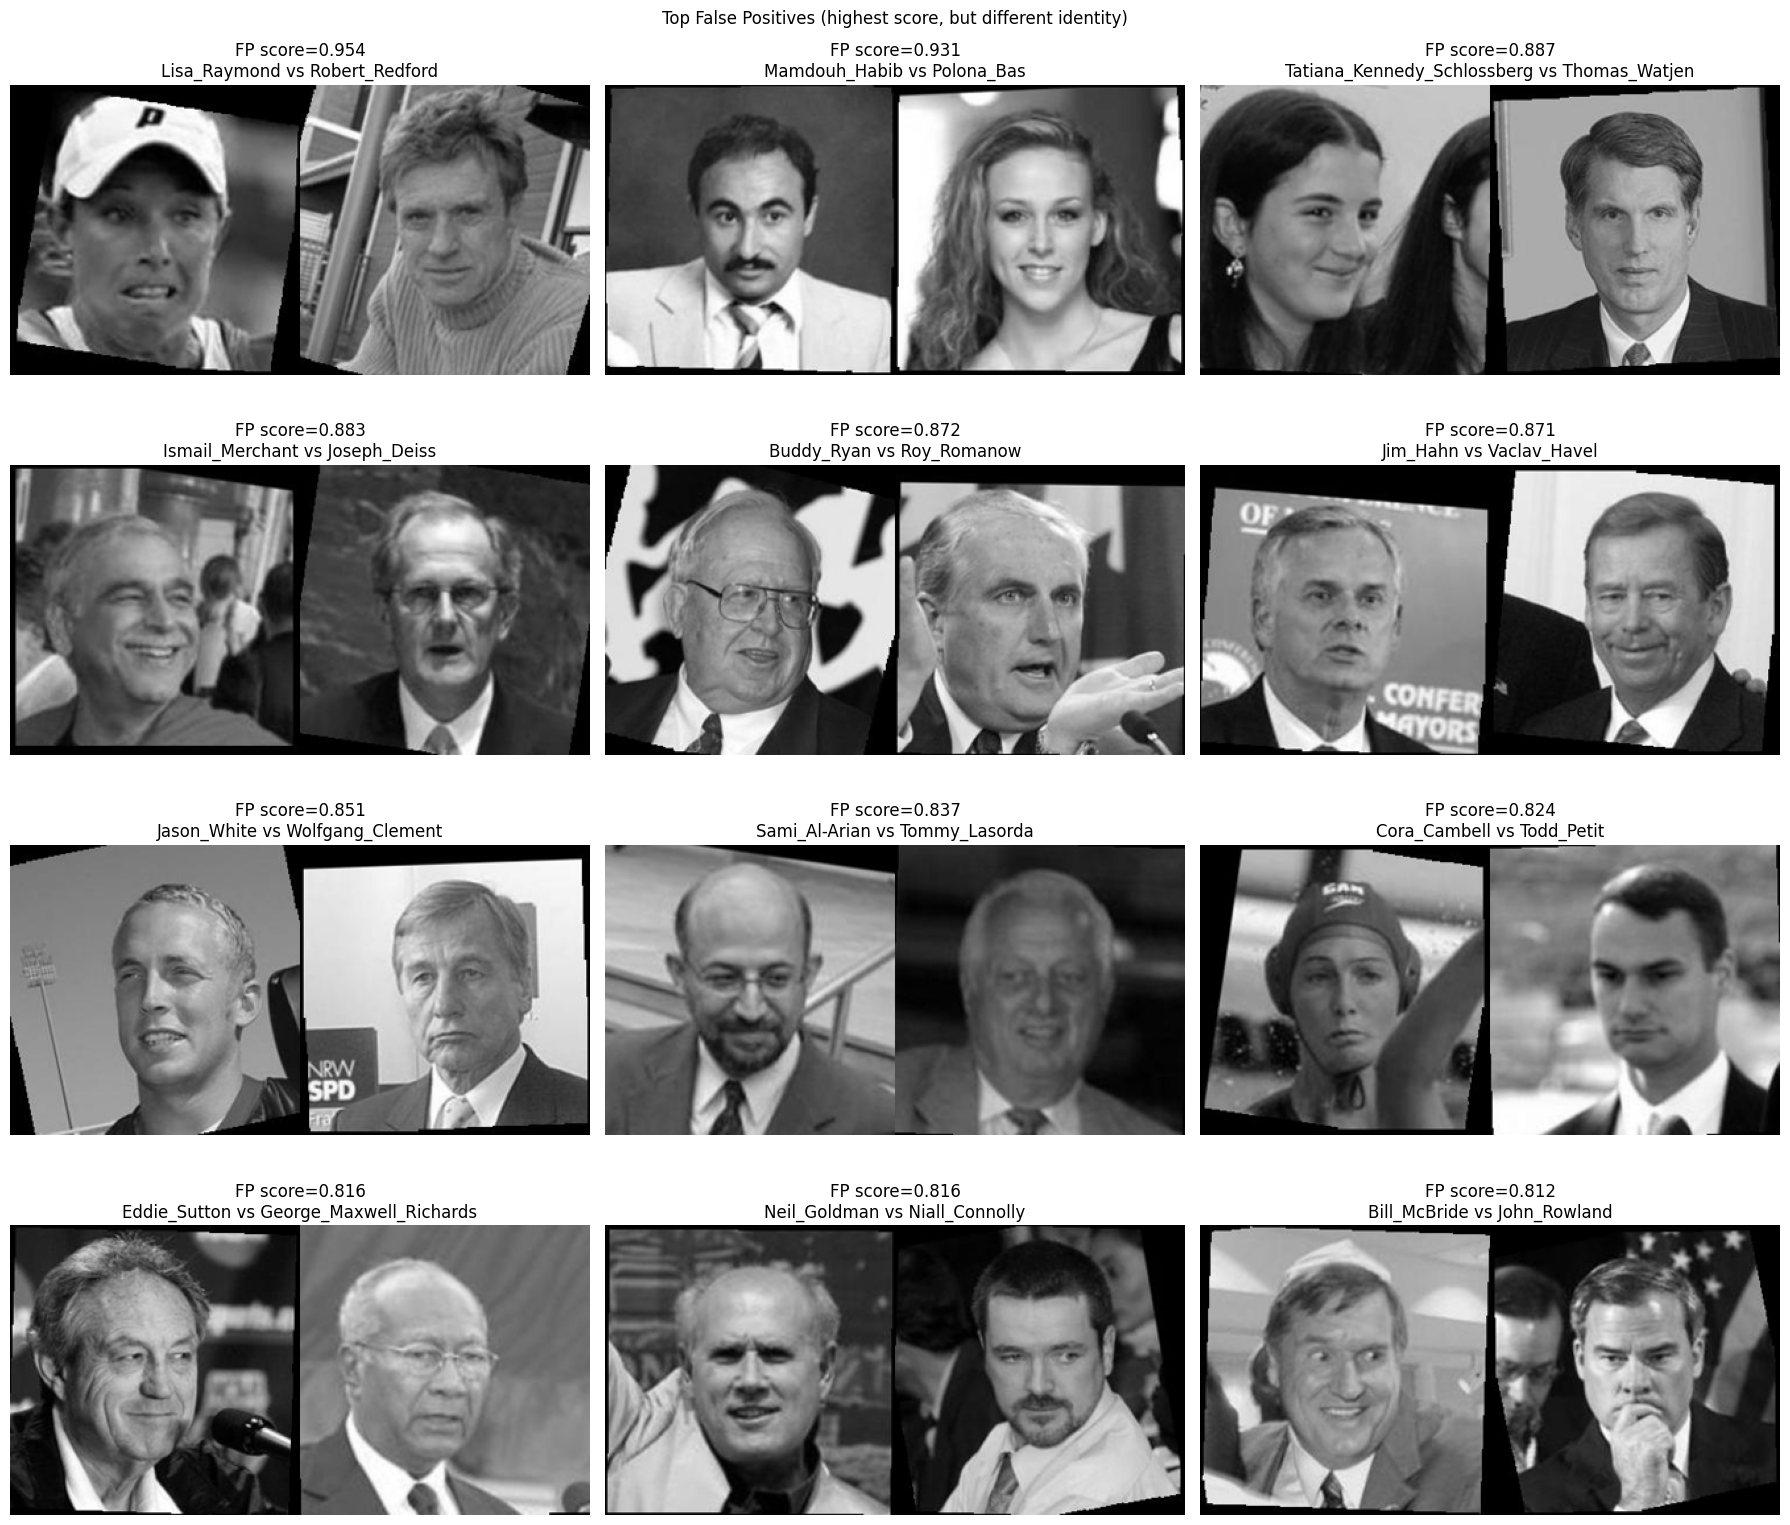

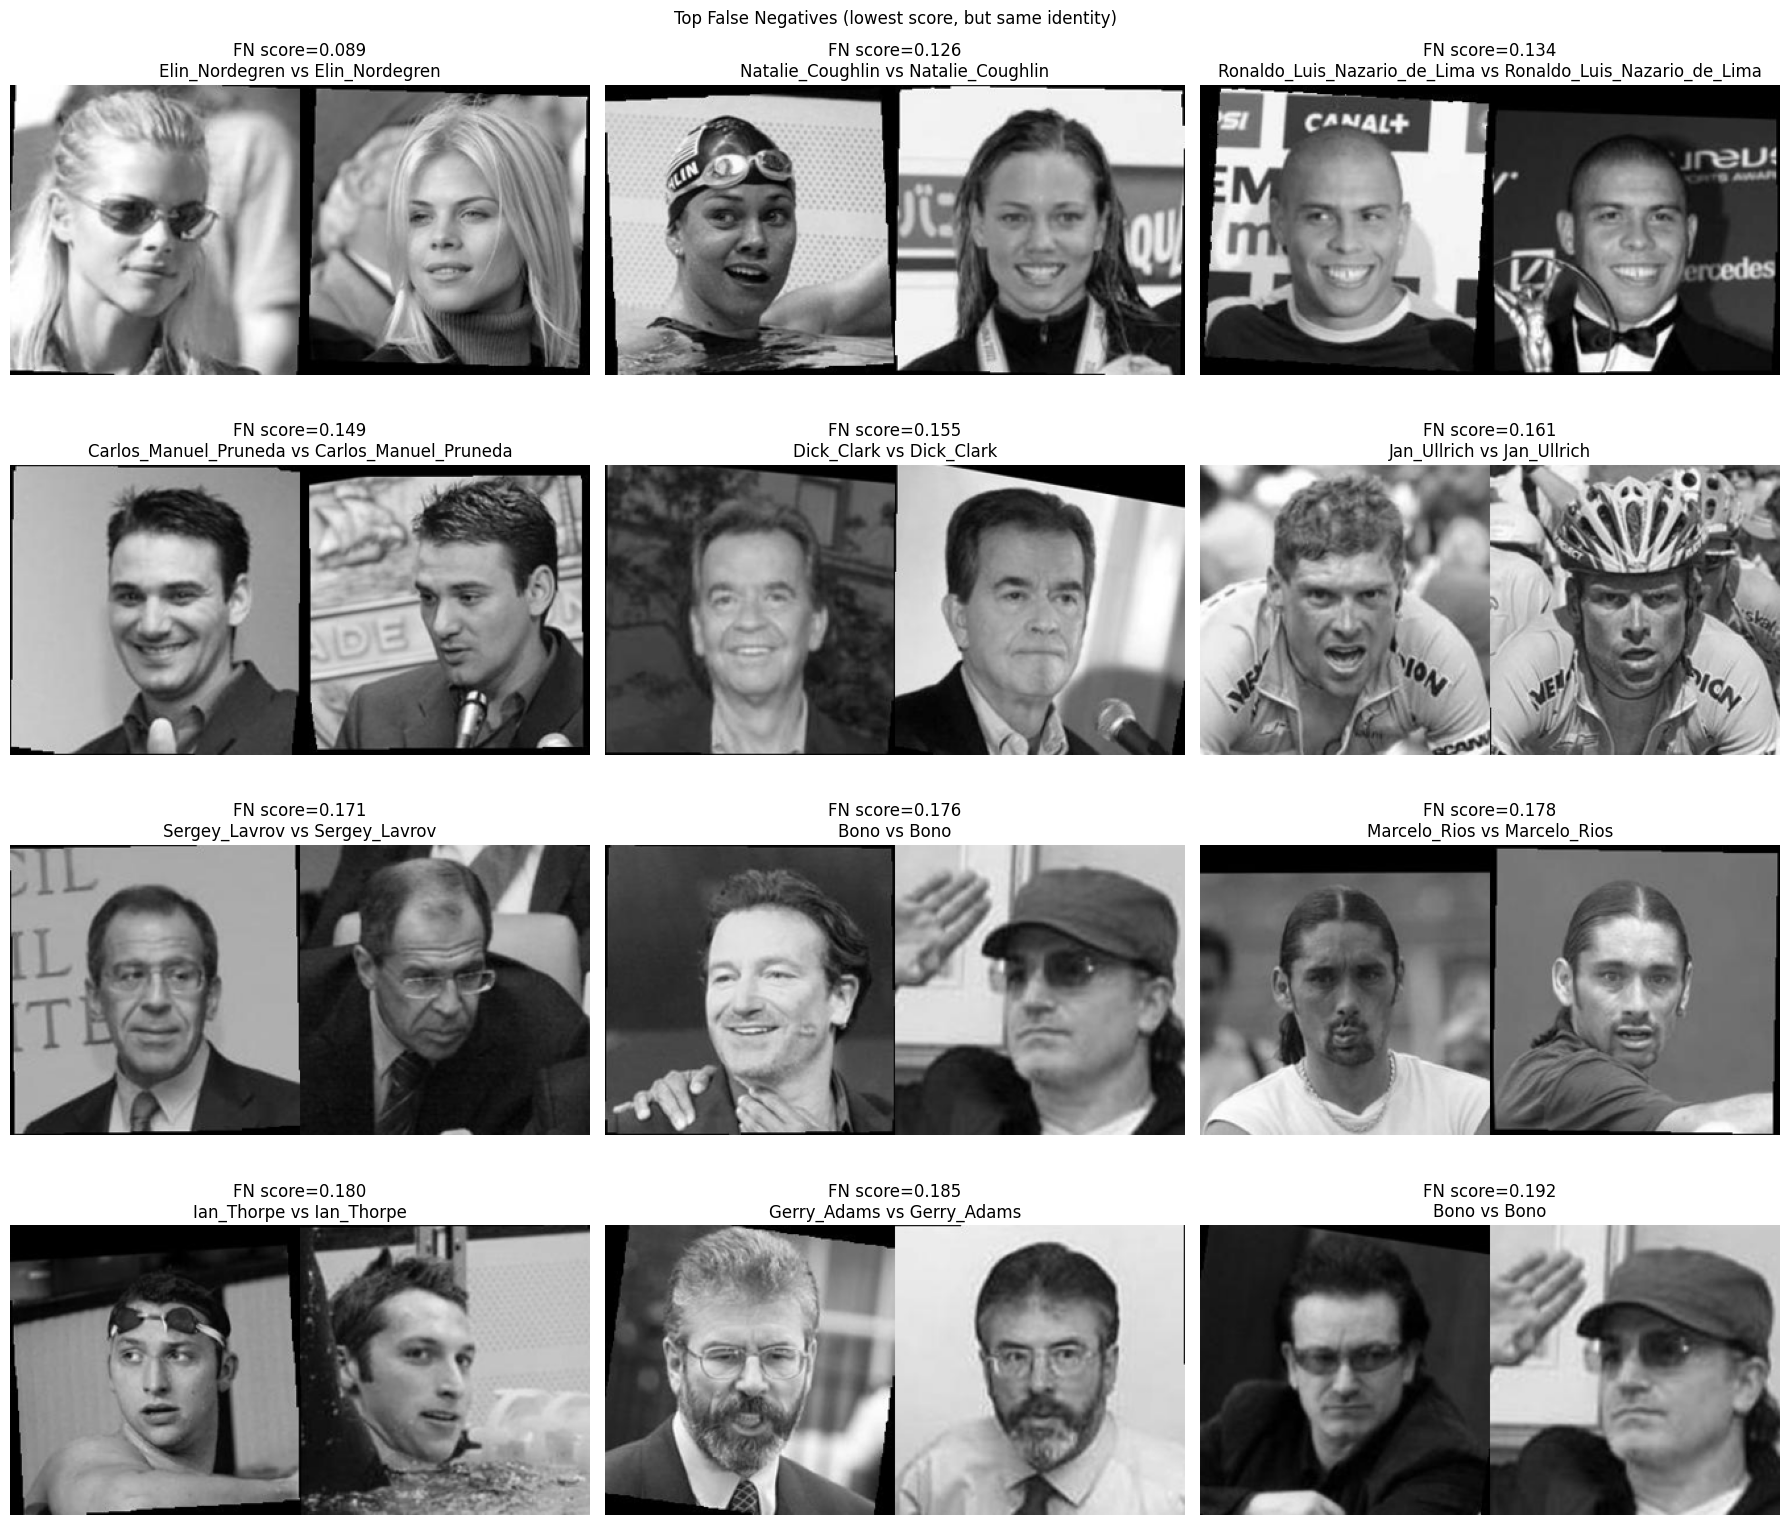

In [45]:
# -------------------------
# Visualize pairs (images side-by-side)
# -------------------------
from PIL import Image

def show_pairs(df_subset: pd.DataFrame, title: str, n: int = 12, max_w: int = 220):
    n = min(n, len(df_subset))
    if n == 0:
        print("No samples to show:", title)
        return

    cols = 3
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols*6, rows*4))
    for i in range(n):
        r = df_subset.iloc[i]
        img1 = Image.open(r["img1"]).convert("RGB")
        img2 = Image.open(r["img2"]).convert("RGB")

        # simple resize for display
        def resize(im):
            w, h = im.size
            if w > max_w:
                s = max_w / w
                im = im.resize((int(w*s), int(h*s)))
            return im

        img1 = resize(img1)
        img2 = resize(img2)

        canvas = Image.new("RGB", (img1.size[0] + img2.size[0], max(img1.size[1], img2.size[1])), (0,0,0))
        canvas.paste(img1, (0,0))
        canvas.paste(img2, (img1.size[0],0))

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(canvas)
        ax.axis("off")
        ax.set_title(f"{r['error_type']} score={r['score']:.3f}\n{r['id1']} vs {r['id2']}")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_pairs(fps, "Top False Positives (highest score, but different identity)", n=12)
show_pairs(fns, "Top False Negatives (lowest score, but same identity)", n=12)


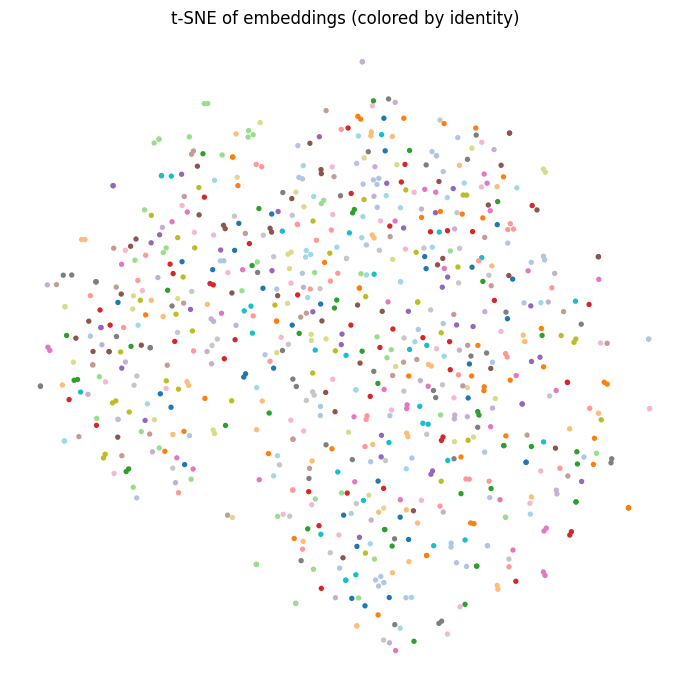

In [49]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# -------------------------
# Sample (keep it fast)
# -------------------------
sample_n = min(800, len(df))
sdf = df.sample(sample_n, random_state=42).reset_index(drop=True)

# -------------------------
# Load embeddings
# -------------------------
E = np.stack(
    sdf["e1"].apply(lambda x: np.array(json.loads(x) if isinstance(x, str) else x)).values
)

labels = sdf["id1"].values

# -------------------------
# t-SNE
# -------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)
Z = tsne.fit_transform(E)

# -------------------------
# Color by identity
# -------------------------
uniq_ids = np.unique(labels)
id_to_int = {id_: i for i, id_ in enumerate(uniq_ids)}
colors = np.array([id_to_int[l] for l in labels])

plt.figure(figsize=(7, 7))
plt.scatter(Z[:, 0], Z[:, 1], c=colors, cmap="tab20", s=8)
plt.title("t-SNE of embeddings (colored by identity)")
plt.axis("off")
plt.tight_layout()
plt.show()


Confusion matrix:
[[329 171]
 [181 319]]

Rows: true labels [0=Different, 1=Same]
Cols: predicted labels [0=Different, 1=Same]


<Figure size 500x500 with 0 Axes>

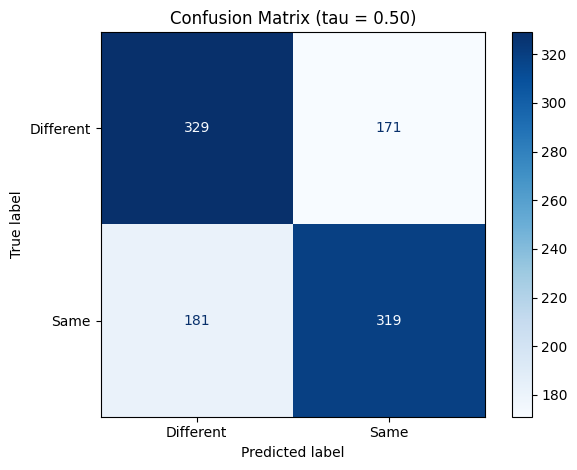

In [50]:
# -------------------------
# Confusion matrix
# -------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# If dfa does not exist yet, create it
if "dfa" not in globals():
    tau = 0.5
    dfa = apply_threshold(df, tau)

y_true = dfa["y_true"].values
y_pred = dfa["y_pred"].values

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix:")
print(cm)
print("\nRows: true labels [0=Different, 1=Same]")
print("Cols: predicted labels [0=Different, 1=Same]")

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Different", "Same"]
)

plt.figure(figsize=(5, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix (tau = {tau:.2f})")
plt.grid(False)
plt.tight_layout()
plt.show()
